# Clustering on Iris Dataset

### Aim
To apply **K-Means Clustering** and **Agglomerative Hierarchical Clustering** on the Iris dataset, visualize the clusters, compute **Silhouette Scores**, and compare both methods.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

plt.style.use("seaborn-v0_8")

## Load the Iris Dataset
The Iris dataset is loaded using Scikit-learn.

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Select Feature Variables
All four feature variables are selected for clustering.

In [3]:
X = df.copy()

print("Selected Features:")
print(X.columns.tolist())
print("\nShape of dataset:", X.shape)

Selected Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Shape of dataset: (150, 4)


## Apply K-Means Clustering
K-Means clustering is applied with **3 clusters**.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

df["KMeans_Cluster"] = kmeans_labels
df[["KMeans_Cluster"]].head()

,KMeans_Cluster
0,1
1,1
2,1
3,1
4,1


## Visualize K-Means Clusters
A scatter plot is used to visualize the K-Means clusters using the first two features.

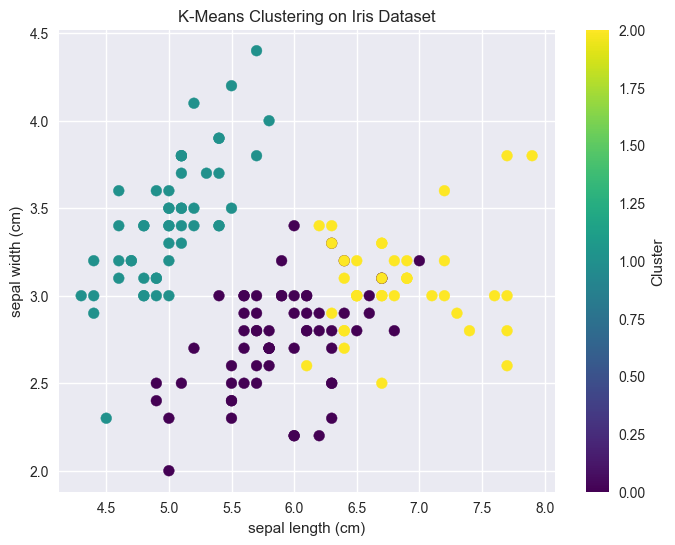

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=kmeans_labels, cmap="viridis", s=60)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("K-Means Clustering on Iris Dataset")
plt.colorbar(label="Cluster")
plt.show()

## Silhouette Score for K-Means
The Silhouette Score is computed to evaluate clustering performance.

In [6]:
kmeans_silhouette = silhouette_score(X, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")

K-Means Silhouette Score: 0.5528


### Conclusion
A higher Silhouette Score indicates better-defined clusters.  
The above score shows the clustering quality of the K-Means algorithm on the Iris dataset.

## Apply Agglomerative Hierarchical Clustering
Agglomerative Hierarchical Clustering is applied with **3 clusters**.

In [7]:
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X)

df["Agglomerative_Cluster"] = agglo_labels
df[["Agglomerative_Cluster"]].head()

,Agglomerative_Cluster
0,1
1,1
2,1
3,1
4,1


## Plot the Dendrogram
A dendrogram is plotted to visualize the hierarchical clustering structure.

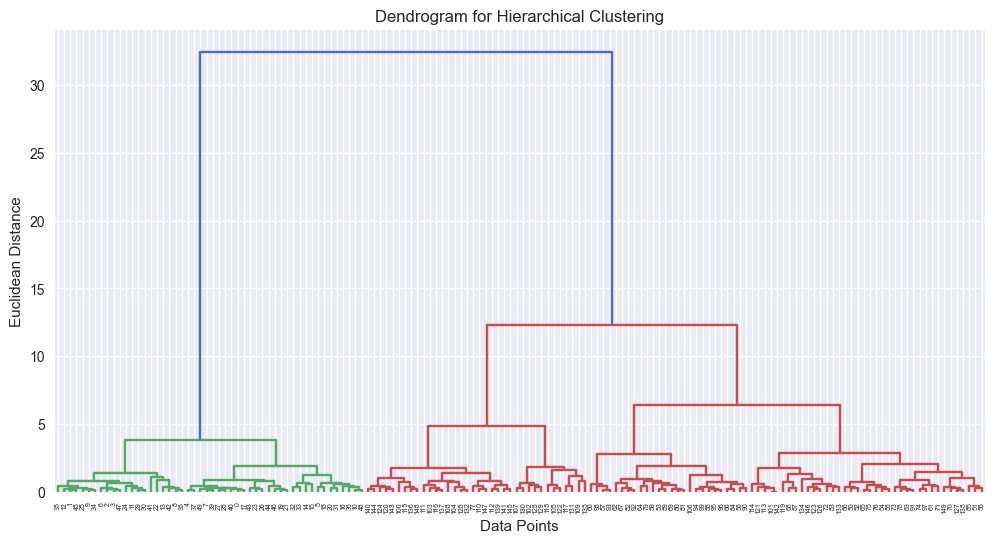

In [8]:
linked = linkage(X, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Visualize Agglomerative Clusters
The generated cluster labels are visualized using a scatter plot.

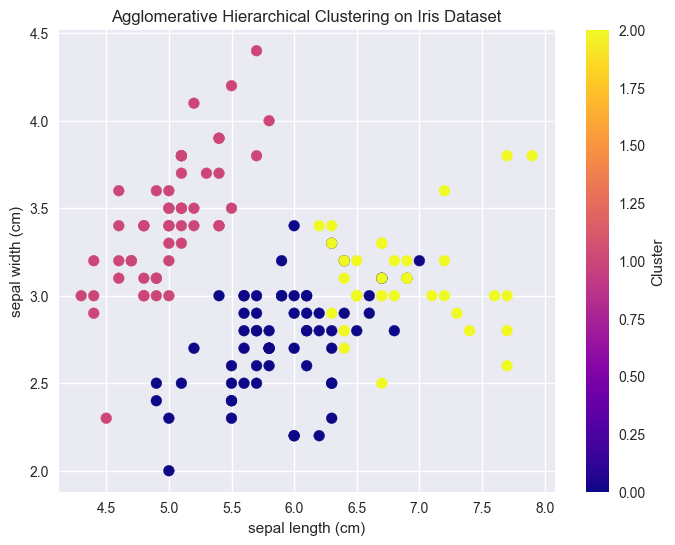

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=agglo_labels, cmap="plasma", s=60)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Agglomerative Hierarchical Clustering on Iris Dataset")
plt.colorbar(label="Cluster")
plt.show()

## Silhouette Score for Hierarchical Clustering
The Silhouette Score is computed to evaluate hierarchical clustering performance.

In [10]:
agglo_silhouette = silhouette_score(X, agglo_labels)
print(f"Agglomerative Hierarchical Clustering Silhouette Score: {agglo_silhouette:.4f}")

Agglomerative Hierarchical Clustering Silhouette Score: 0.5543


## Compare the Silhouette Scores
Both clustering methods are compared using their Silhouette Scores.

In [11]:
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Agglomerative Clustering Silhouette Score: {agglo_silhouette:.4f}")

if kmeans_silhouette > agglo_silhouette:
    print("\nConclusion: K-Means performed better based on the Silhouette Score.")
elif agglo_silhouette > kmeans_silhouette:
    print("\nConclusion: Agglomerative Hierarchical Clustering performed better based on the Silhouette Score.")
else:
    print("\nConclusion: Both methods performed equally based on the Silhouette Score.")

K-Means Silhouette Score: 0.5528
Agglomerative Clustering Silhouette Score: 0.5543

Conclusion: Agglomerative Hierarchical Clustering performed better based on the Silhouette Score.


## Final Conclusion
- The **Iris dataset** was clustered using both **K-Means** and **Agglomerative Hierarchical Clustering**.
- Scatter plots were used to visualize the clusters.
- A dendrogram was plotted for hierarchical clustering.
- **Silhouette Scores** were calculated for both methods.
- The method with the higher Silhouette Score is considered better for this dataset.